In [1]:
%pip -q install "datasets==3.6.0" torchaudio tqdm
import datasets
print("datasets:", datasets.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 14.2 MB/s eta 0:00:00
datasets: 3.6.0


In [8]:
%pip -q install scikit-learn seaborn


# Load from Drive

In [9]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import os, glob

SAVE_ROOT = "/content/drive/MyDrive/fleurs_preprocessed/south_asian"
train_shards = os.path.join(SAVE_ROOT, "train_shards")
val_shards   = os.path.join(SAVE_ROOT, "validation_shards")
test_shards  = os.path.join(SAVE_ROOT, "test_shards")

print("SAVE_ROOT:", SAVE_ROOT)
print("Exists train_shards?", os.path.exists(train_shards))
print("Exists val_shards?", os.path.exists(val_shards))
print("Exists test_shards?", os.path.exists(test_shards))

print("Train .pt files:", len(glob.glob(os.path.join(train_shards, "*.pt"))))
print("Val .pt files:",   len(glob.glob(os.path.join(val_shards, "*.pt"))))
print("Test .pt files:",  len(glob.glob(os.path.join(test_shards, "*.pt"))))


Mounted at /content/drive
SAVE_ROOT: /content/drive/MyDrive/fleurs_preprocessed/south_asian
Exists train_shards? True
Exists val_shards? True
Exists test_shards? True
Train .pt files: 31
Val .pt files: 7
Test .pt files: 9


In [10]:
import os
import torch
import torchaudio
from tqdm import tqdm
from datasets import load_dataset, interleave_datasets, DatasetDict


# Robust loader (auto-retry if Drive disconnects)

In [15]:
import torch, time

def safe_torch_load(path, retries=2):
    for attempt in range(retries + 1):
        try:
            return torch.load(path, weights_only=False)
        except OSError as e:
            # Drive mount can drop -> Errno 107
            if "Transport endpoint is not connected" in str(e) and attempt < retries:
                print(f"[WARN] Drive disconnected while reading {path}. Remounting... (attempt {attempt+1}/{retries})")
                drive.mount("/content/drive", force_remount=True)
                time.sleep(1)
                continue
            raise

def load_all_shards(shard_dir):
    files = sorted(glob.glob(os.path.join(shard_dir, "*.pt")))
    data = []
    for f in files:
        data.extend(safe_torch_load(f))
    return data


# Load train/val/test from shards

In [16]:
train_data = load_all_shards(train_shards)
val_data   = load_all_shards(val_shards)
test_data  = load_all_shards(test_shards)

print("Train:", len(train_data), "Val:", len(val_data), "Test:", len(test_data))
print("Example:", train_data[0]["x"].shape, train_data[0]["y"], train_data[0]["language"])


Train: 15134 Val: 3346 Test: 4186
Example: torch.Size([1915, 80]) 8 Oriya


# Dataset + collate_fnn

In [17]:
import torch
from torch.utils.data import Dataset, DataLoader

class PreprocessedDataset(Dataset):
    def __init__(self, data): self.data = data
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        item = self.data[idx]
        return item["x"], item["y"]  # x:[T,80], y:int

def collate_fnn(batch):
    xs, ys = zip(*batch)
    pooled = [x.mean(dim=0) for x in xs]   # [80]
    X = torch.stack(pooled, dim=0)         # [B,80]
    y = torch.tensor(ys, dtype=torch.long) # [B]
    return X, y


In [18]:
BATCH_SIZE = 256

train_loader_fnn = DataLoader(PreprocessedDataset(train_data), batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fnn)
val_loader_fnn   = DataLoader(PreprocessedDataset(val_data),   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fnn)
test_loader_fnn  = DataLoader(PreprocessedDataset(test_data),  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fnn)

X, y = next(iter(train_loader_fnn))
print("X:", X.shape, "y:", y.shape)


X: torch.Size([256, 80]) y: torch.Size([256])


# Train + Eval

In [19]:
import numpy as np
import torch.nn as nn

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss/total, correct/total

@torch.no_grad()
def evaluate(model, loader, criterion, device, return_preds=False):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        loss = criterion(logits, y)
        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        if return_preds:
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())
    if return_preds:
        return total_loss/total, correct/total, torch.cat(all_labels).numpy(), torch.cat(all_preds).numpy()
    return total_loss/total, correct/total


# FNN (Simple)

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 14
print("device:", device, "| NUM_CLASSES:", NUM_CLASSES)

class FNNBaseline(nn.Module):
    def __init__(self, input_dim=80, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )
    def forward(self, x): return self.net(x)

model_base = FNNBaseline().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_base.parameters(), lr=1e-3)


device: cpu | NUM_CLASSES: 14


[BASE] Epoch 01/10 | train_loss=2.8024 train_acc=0.0786 | val_loss=2.6403 val_acc=0.0209
[BASE] Epoch 02/10 | train_loss=2.5589 train_acc=0.1164 | val_loss=2.6702 val_acc=0.0293
[BASE] Epoch 03/10 | train_loss=2.4250 train_acc=0.1770 | val_loss=2.8172 val_acc=0.1300
[BASE] Epoch 04/10 | train_loss=2.3038 train_acc=0.2255 | val_loss=2.8518 val_acc=0.0962
[BASE] Epoch 05/10 | train_loss=2.1527 train_acc=0.2717 | val_loss=2.9508 val_acc=0.1213
[BASE] Epoch 06/10 | train_loss=2.0299 train_acc=0.3186 | val_loss=2.9834 val_acc=0.0923
[BASE] Epoch 07/10 | train_loss=1.9019 train_acc=0.3627 | val_loss=3.3066 val_acc=0.1049
[BASE] Epoch 08/10 | train_loss=1.8113 train_acc=0.3965 | val_loss=3.2174 val_acc=0.1255
[BASE] Epoch 09/10 | train_loss=1.7298 train_acc=0.4228 | val_loss=3.3355 val_acc=0.1172
[BASE] Epoch 10/10 | train_loss=1.6497 train_acc=0.4484 | val_loss=3.4546 val_acc=0.1195
[BASE] TEST | loss=3.3599 acc=0.1350


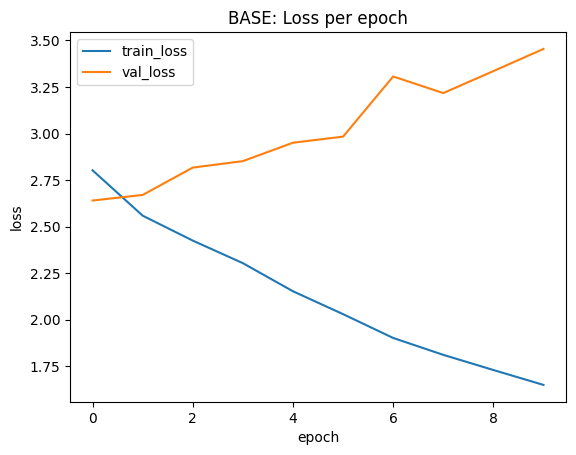

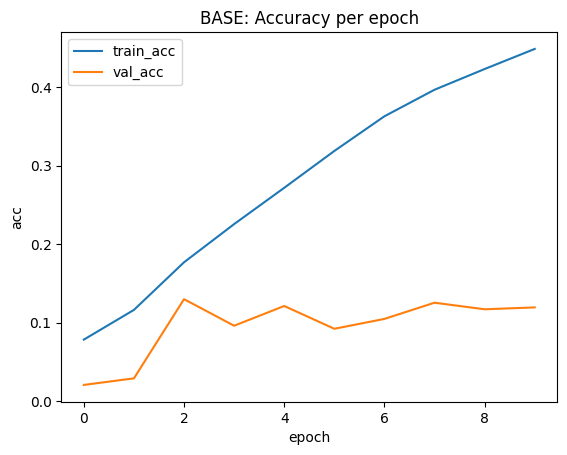

In [21]:
import matplotlib.pyplot as plt

history_base = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
num_epochs = 10

for epoch in range(1, num_epochs+1):
    tr_loss, tr_acc = train_one_epoch(model_base, train_loader_fnn, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model_base, val_loader_fnn, criterion, device)
    history_base["train_loss"].append(tr_loss); history_base["train_acc"].append(tr_acc)
    history_base["val_loss"].append(va_loss);   history_base["val_acc"].append(va_acc)
    print(f"[BASE] Epoch {epoch:02d}/{num_epochs} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

te_loss, te_acc = evaluate(model_base, test_loader_fnn, criterion, device)
print(f"[BASE] TEST | loss={te_loss:.4f} acc={te_acc:.4f}")

plt.figure()
plt.plot(history_base["train_loss"], label="train_loss")
plt.plot(history_base["val_loss"], label="val_loss")
plt.legend(); plt.title("BASE: Loss per epoch"); plt.xlabel("epoch"); plt.ylabel("loss"); plt.show()

plt.figure()
plt.plot(history_base["train_acc"], label="train_acc")
plt.plot(history_base["val_acc"], label="val_acc")
plt.legend(); plt.title("BASE: Accuracy per epoch"); plt.xlabel("epoch"); plt.ylabel("acc"); plt.show()


# Upgraded FNN (BatchNorm + AdamW)

In [22]:
class FNN_BN(nn.Module):
    def __init__(self, input_dim=80, num_classes=NUM_CLASSES, dropout=0.35):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )
    def forward(self, x): return self.net(x)

model_up = FNN_BN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_up.parameters(), lr=3e-4, weight_decay=1e-2)


In [23]:
import copy

history_up = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
num_epochs = 30
best_val_acc, best_epoch, best_state = -1.0, -1, None

for epoch in range(1, num_epochs+1):
    tr_loss, tr_acc = train_one_epoch(model_up, train_loader_fnn, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model_up, val_loader_fnn, criterion, device)

    history_up["train_loss"].append(tr_loss); history_up["train_acc"].append(tr_acc)
    history_up["val_loss"].append(va_loss);   history_up["val_acc"].append(va_acc)

    print(f"[UP] Epoch {epoch:02d}/{num_epochs} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

    if va_acc > best_val_acc:
        best_val_acc, best_epoch = va_acc, epoch
        best_state = copy.deepcopy(model_up.state_dict())
        print(f"  ✅ best val_acc={best_val_acc:.4f} at epoch {best_epoch}")

model_up.load_state_dict(best_state)
print(f"Restored best checkpoint: epoch={best_epoch}, val_acc={best_val_acc:.4f}")


[UP] Epoch 01/30 | train_loss=2.3362 train_acc=0.2465 | val_loss=2.7697 val_acc=0.1115
  ✅ best val_acc=0.1115 at epoch 1
[UP] Epoch 02/30 | train_loss=1.9022 train_acc=0.4353 | val_loss=2.7980 val_acc=0.1070
[UP] Epoch 03/30 | train_loss=1.5801 train_acc=0.5513 | val_loss=2.8166 val_acc=0.1189
  ✅ best val_acc=0.1189 at epoch 3
[UP] Epoch 04/30 | train_loss=1.3336 train_acc=0.6293 | val_loss=2.8437 val_acc=0.1336
  ✅ best val_acc=0.1336 at epoch 4
[UP] Epoch 05/30 | train_loss=1.1267 train_acc=0.6822 | val_loss=2.9738 val_acc=0.1506
  ✅ best val_acc=0.1506 at epoch 5
[UP] Epoch 06/30 | train_loss=0.9708 train_acc=0.7299 | val_loss=3.0058 val_acc=0.1539
  ✅ best val_acc=0.1539 at epoch 6
[UP] Epoch 07/30 | train_loss=0.8631 train_acc=0.7593 | val_loss=3.0832 val_acc=0.1647
  ✅ best val_acc=0.1647 at epoch 7
[UP] Epoch 08/30 | train_loss=0.7643 train_acc=0.7881 | val_loss=3.1697 val_acc=0.1554
[UP] Epoch 09/30 | train_loss=0.6907 train_acc=0.8048 | val_loss=3.3626 val_acc=0.1503
[UP] Ep

In [25]:
import matplotlib.pyplot as plt

def plot_history(history, title_prefix="Model", mark_epoch=None, mark_label="mark"):
    """
    history: dict with keys: train_loss, val_loss, train_acc, val_acc (lists)
    mark_epoch: (optional) 1-based epoch index to highlight with red dot + vertical line
    """
    n = len(history["train_loss"])
    epochs = list(range(1, n + 1))

    # --- Loss plot ---
    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")

    if mark_epoch is not None and 1 <= mark_epoch <= n:
        idx = mark_epoch - 1
        plt.scatter([mark_epoch], [history["val_loss"][idx]], color="red", zorder=5, label=f"{mark_label} @ {mark_epoch}")
        plt.axvline(mark_epoch, color="red", linestyle="--", alpha=0.6)

    plt.legend()
    plt.title(f"{title_prefix}: Loss per epoch")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.show()

    # --- Accuracy plot ---
    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")

    if mark_epoch is not None and 1 <= mark_epoch <= n:
        idx = mark_epoch - 1
        plt.scatter([mark_epoch], [history["val_acc"][idx]], color="red", zorder=5, label=f"{mark_label} @ {mark_epoch}")
        plt.axvline(mark_epoch, color="red", linestyle="--", alpha=0.6)

    plt.legend()
    plt.title(f"{title_prefix}: Accuracy per epoch")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.show()


In [26]:
def best_epoch_from_history(history):
    best_idx = int(max(range(len(history["val_acc"])), key=lambda i: history["val_acc"][i]))
    return best_idx + 1  # convert to 1-based


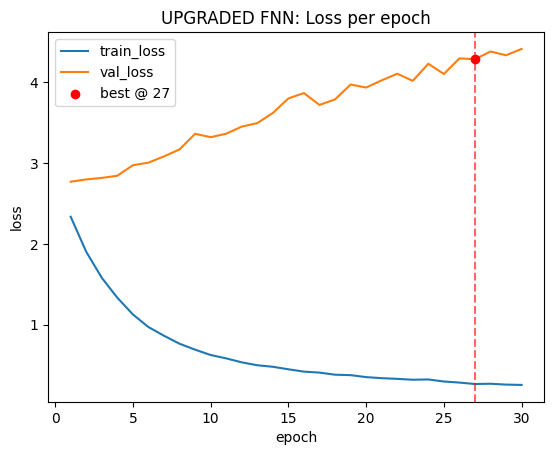

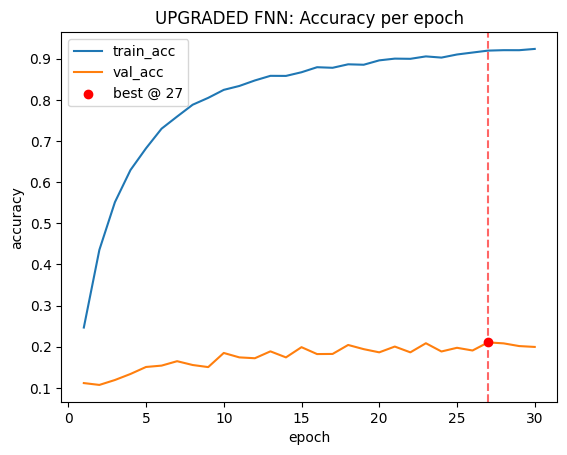

In [27]:
best_ep = best_epoch_from_history(history_up)
plot_history(history_up, title_prefix="UPGRADED FNN", mark_epoch=best_ep, mark_label="best")


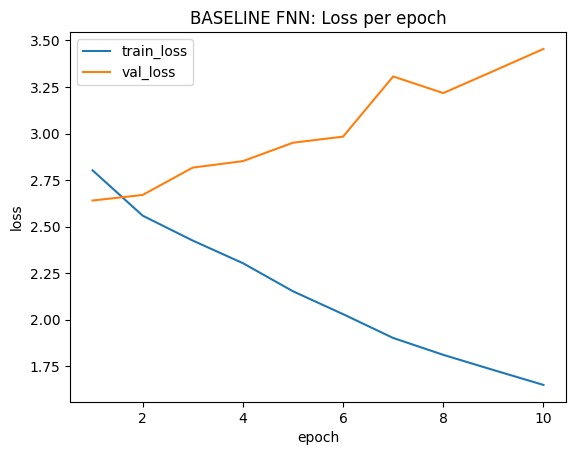

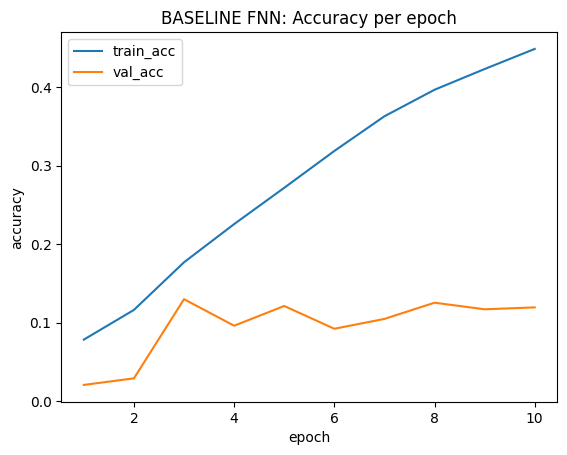

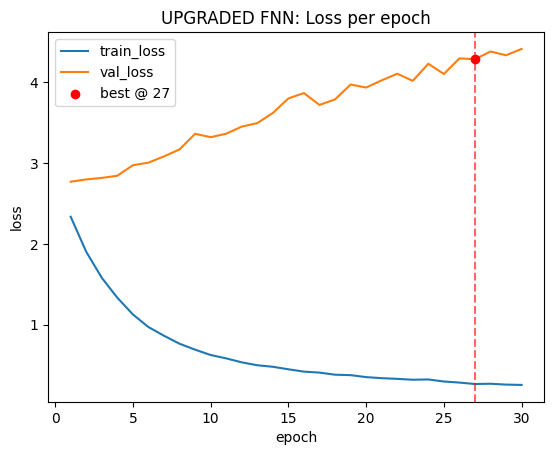

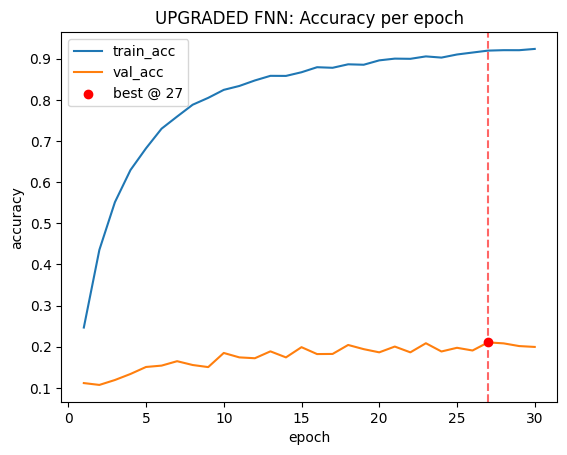

In [28]:
plot_history(history_base, title_prefix="BASELINE FNN")
best_ep = best_epoch_from_history(history_up)
plot_history(history_up, title_prefix="UPGRADED FNN", mark_epoch=best_ep, mark_label="best")


[UP] TEST | loss=4.2971 acc=0.2205 (sklearn acc=0.2205)


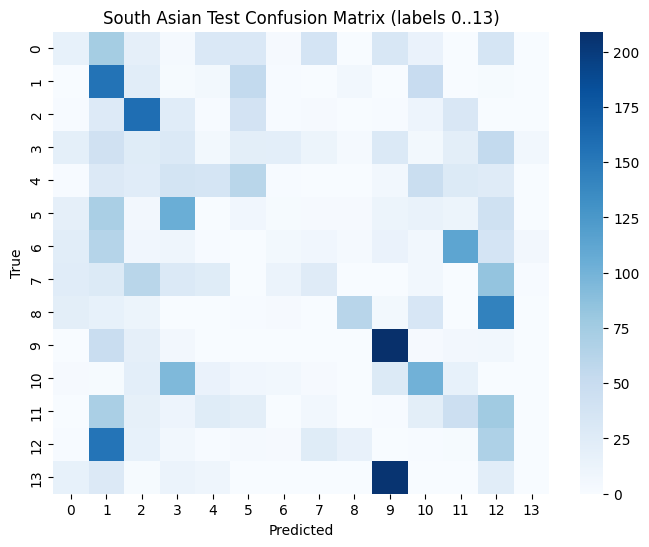

In [24]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

te_loss, te_acc, y_true, y_pred = evaluate(model_up, test_loader_fnn, criterion, device, return_preds=True)
print(f"[UP] TEST | loss={te_loss:.4f} acc={te_acc:.4f} (sklearn acc={accuracy_score(y_true, y_pred):.4f})")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues")
plt.title("South Asian Test Confusion Matrix (labels 0..13)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


On the South Asian subset (14 languages), the upgraded FNN achieves ~22% test accuracy (≈3× chance). The confusion matrix shows the model correctly identifies some languages reliably (strong diagonal cells), but makes systematic errors between linguistically similar languages—especially Urdu being frequently misclassified as Punjabi.